Laplaciano simple

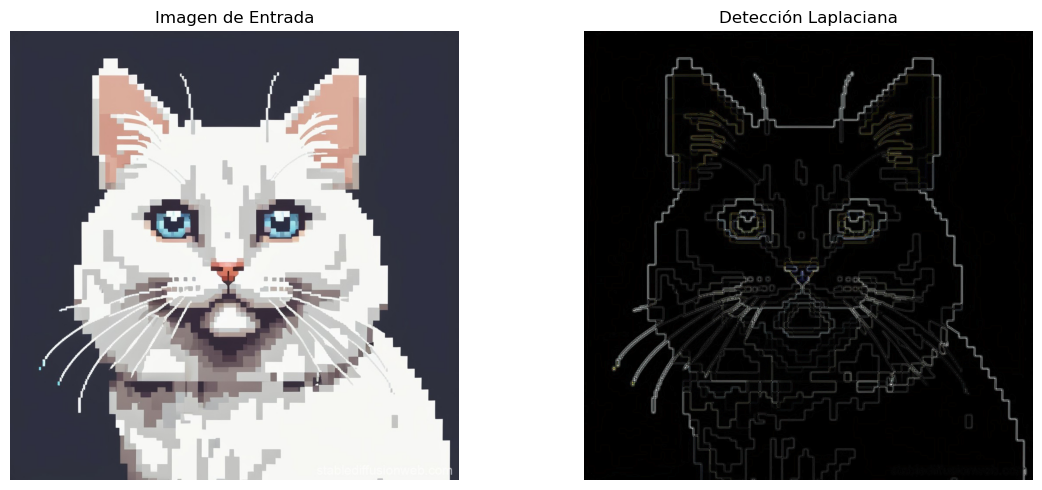

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
imagen_src = cv2.imread('imagen1.jpg')

# Aplicar un filtro Gaussiano para reducir el ruido
suavizado_gauss = cv2.GaussianBlur(imagen_src, (5, 5), 0)

# Aplicar el operador Laplaciano
laplaciano = cv2.Laplacian(suavizado_gauss, cv2.CV_64F, ksize=3)
laplaciano_visual = cv2.convertScaleAbs(laplaciano)

# Configurar la visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(imagen_src, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen de Entrada')
axes[0].axis('off')

axes[1].imshow(laplaciano_visual, cmap='gray')
axes[1].set_title('Detección Laplaciana')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Laplaciano del Gaussiano (LoG)

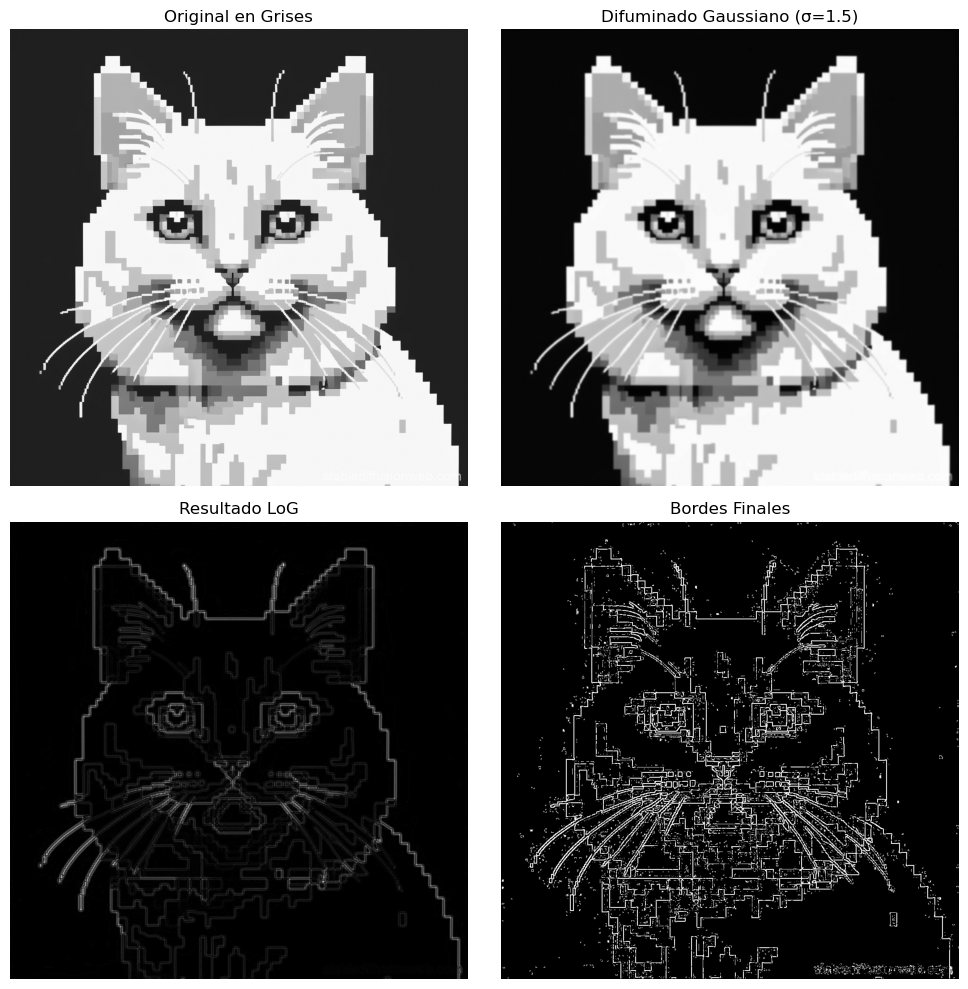

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen directamente en escala de grises
imagen_gris = cv2.imread('imagen1.jpg', 0)

# Definir parámetros para el filtro
valor_sigma = 1.5
tamano_kernel = int(6 * valor_sigma + 1)
tamano_kernel = tamano_kernel if tamano_kernel % 2 != 0 else tamano_kernel + 1

# Paso 1: Suavizado Gaussiano
img_difuminada = cv2.GaussianBlur(imagen_gris, (tamano_kernel, tamano_kernel), valor_sigma)

# Paso 2: Derivada (Laplaciano)
operacion_laplaciana = cv2.Laplacian(img_difuminada, cv2.CV_64F, ksize=3)
laplaciano_mostrar = cv2.convertScaleAbs(operacion_laplaciana)

# Paso 3: Encontrar los cruces por cero (Zero-crossing)
umbral_tolerancia = 0.025 * np.max(np.abs(operacion_laplaciana))
mapa_bordes = np.zeros_like(operacion_laplaciana, dtype=np.uint8)
filas, columnas = operacion_laplaciana.shape

for i in range(1, filas - 1):
    for j in range(1, columnas - 1):
        pixel_actual = operacion_laplaciana[i, j]
        vecindad = operacion_laplaciana[i-1:i+2, j-1:j+2]
        
        # Condición de cruce por cero evaluando la matriz 3x3
        if (pixel_actual > 0 and np.min(vecindad) < -umbral_tolerancia) or \
        (pixel_actual < 0 and np.max(vecindad) > umbral_tolerancia):
            mapa_bordes[i, j] = 255

# Paso 4: Graficar los resultados en una cuadrícula 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(imagen_gris, cmap='gray')
axs[0, 0].set_title('Original en Grises')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_difuminada, cmap='gray')
axs[0, 1].set_title(f'Difuminado Gaussiano (σ={valor_sigma})')
axs[0, 1].axis('off')

axs[1, 0].imshow(laplaciano_mostrar, cmap='gray')
axs[1, 0].set_title('Resultado LoG')
axs[1, 0].axis('off')

axs[1, 1].imshow(mapa_bordes, cmap='gray')
axs[1, 1].set_title('Bordes Finales')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()